Objectif : Déterminer la presence de la Bactériemie (valeur cible déséquilibré)

Dans ce projet, nous visons à développer un modèle de prédiction permettant de détecter la survenue d'une bactériémie chez des patients hospitalisés présentant une suspicion clinique. Le modèle sera construit à partir d'un ensemble de données de 11 753 observations, contenant 51 variables prédictives, collectées à l'Hôpital général de Vienne entre 2006 et 2010.

Notre approche implique le prétraitement des données, incluant la gestion des valeurs manquantes, la normalisation des variables pertinentes et l'encodage des variables catégorielles. Nous testerons plusieurs algorithmes de machine learning, tels que les régressions logistiques, les forêts aléatoires, et les réseaux de neurones, afin d'identifier le modèle offrant les meilleures performances en termes de F1-score. Une validation croisée sera utilisée pour évaluer la robustesse du modèle.

Les performances du modèle seront comparées en utilisant principalement le F1 score, avec un accent sur la précision et le rappel pour garantir une bonne capacité de généralisation. Le modèle final sera implémenté dans un script Python capable de prédire la survenue d'une bactériémie (0 ou 1) à partir d'un fichier de données d'entrée similaire.

# Import library

In [1]:
import pandas as pd
import numpy as np

# DataManagement
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Split train/test
from sklearn.model_selection import train_test_split

# Modèle
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# SMOTE (donnée déséquilibré)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Evaluation
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Import files

In [2]:
!gdown 1uxKSuIhzwAUazK1mjjkW78Nbg8WUqhl8 -O bacteriemie.csv

Downloading...
From: https://drive.google.com/uc?id=1uxKSuIhzwAUazK1mjjkW78Nbg8WUqhl8
To: /content/bacteriemie.csv
100% 2.95M/2.95M [00:00<00:00, 43.8MB/s]


In [3]:
!gdown 1C8oPW2kgxzY5BA8IVFLowJi3mn1F_28Z -O bacteriemie_test.csv

Downloading...
From: https://drive.google.com/uc?id=1C8oPW2kgxzY5BA8IVFLowJi3mn1F_28Z
To: /content/bacteriemie_test.csv
100% 728k/728k [00:00<00:00, 88.6MB/s]


In [4]:
df = pd.read_csv("bacteriemie.csv", sep =",")
Bacteriemie_test = pd.read_csv("bacteriemie_test.csv", sep =";")
df.head()

,ID,SEX,AGE,MCV,HGB,HCT,PLT,MCH,MCHC,RDW,...,BASOR,EOSR,LYMR,MONOR,NEU,NEUR,PDW,RBC,WBC,BloodCulture
0,1,2,62,99.3,11.5,35.9,307.0,31.5,31.8,19.5,...,0.413223,0.000000,1.652893,7.024793,22.0,90.909091,10.6,3.7,24.10,no
1,3,1,72,85.1,10.3,34.7,182.0,26.0,30.6,15.0,...,0.000000,0.826446,3.305785,1.652893,11.4,94.214876,11.4,3.9,12.17,no
2,5,1,46,96.3,7.4,22.8,64.0,31.2,32.4,19.7,...,0.568182,0.568182,8.522727,6.818182,14.7,83.522727,14.1,2.5,17.45,no
3,9,2,38,85.1,13.7,38.7,183.0,30.2,35.3,12.6,...,0.000000,0.000000,8.333333,4.166667,8.4,87.500000,12.2,4.4,9.86,no
4,10,1,68,104.5,15.7,46.9,144.0,34.8,33.5,13.9,...,0.000000,1.000000,22.000000,9.000000,6.8,68.000000,12.9,4.3,9.94,no


# DataManagement

In [5]:
df['BloodCulture'].value_counts()
#df.isnull().sum()
#df.columns.values

,count
BloodCulture,
no,10809
yes,944


In [6]:
numeric_features = ['AGE','MCV', 'HGB', 'HCT', 'PLT', 'MCH', 'MCHC',
       'RDW', 'MPV', 'LYM', 'MONO', 'EOS', 'BASO', 'NT', 'APTT', 'FIB',
       'SODIUM', 'POTASS', 'CA', 'PHOS', 'MG', 'CREA', 'BUN', 'HS',
       'GBIL', 'TP', 'ALB', 'AMY', 'PAMY', 'LIP', 'CHE', 'AP', 'ASAT',
       'ALAT', 'GGT', 'LDH', 'CK', 'GLU', 'TRIG', 'CHOL', 'CRP', 'BASOR',
       'EOSR', 'LYMR', 'MONOR', 'NEU', 'NEUR', 'PDW', 'RBC', 'WBC']
categorical_features = ["SEX"]
BloodCulture = ["BloodCulture"]

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

BloodCulture_transformer = Pipeline([
    ('imputer', SimpleImputer())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

# replace "no" and "yes"
df['BloodCulture'] = df['BloodCulture'].replace({'no': 0, 'yes': 1})

/tmp/ipython-input-3923979471.py:33: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['BloodCulture'] = df['BloodCulture'].replace({'no': 0, 'yes': 1})


# Split train/test

In [7]:
X = df.drop(columns=["BloodCulture"])
y = df["BloodCulture"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Taille X_train :", X_train.shape)
print("Taille X_test :", X_test.shape)
print("Taille y_train :", y_train.shape)
print("Taille y_test :", y_test.shape)

Taille X_train : (9402, 52)
Taille X_test : (2351, 52)
Taille y_train : (9402,)
Taille y_test : (2351,)


# Modèle

In [8]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=500, class_weight='balanced'),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'SVM': SVC(probability=True, class_weight='balanced')
}

In [9]:
results = {}

smote = SMOTE(random_state=42)

for name, clf in models.items():
    pipeline = ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', smote),
        ('classifier', clf)
    ])
    pipeline.fit(X_train, y_train)
    results[name] = pipeline

# Evaluation

In [10]:
y_scores = pipeline.predict_proba(X_test)[:,1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

# Choisir un seuil qui donne un compromis rappel/précision
optimal_threshold = thresholds[np.argmax(2*(precisions*recalls)/(precisions+recalls))]
print("Seuil optimal :", optimal_threshold)

y_pred = (y_scores >= optimal_threshold).astype(int)

Seuil optimal : 0.9948993395025536


/tmp/ipython-input-1157853856.py:5: RuntimeWarning: invalid value encountered in divide
  optimal_threshold = thresholds[np.argmax(2*(precisions*recalls)/(precisions+recalls))]


In [11]:
for name, pipeline in results.items():
    print(f"\n=== Évaluation : {name} ===")
    y_pred = pipeline.predict(X_test)
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
    print(f"Precision : {precision_score(y_test, y_pred):.3f}")
    print(f"Recall : {recall_score(y_test, y_pred):.3f}")
    print(f"F1 score : {f1_score(y_test, y_pred):.3f}")
    print("Matrice de confusion :")
    print(confusion_matrix(y_test, y_pred))
    print("Classification report :")
    print(classification_report(y_test, y_pred))


=== Évaluation : LogisticRegression ===
Accuracy : 0.703
Precision : 0.165
Recall : 0.661
F1 score : 0.264
Matrice de confusion :
[[1528  634]
 [  64  125]]
Classification report :
              precision    recall  f1-score   support

           0       0.96      0.71      0.81      2162
           1       0.16      0.66      0.26       189

    accuracy                           0.70      2351
   macro avg       0.56      0.68      0.54      2351
weighted avg       0.90      0.70      0.77      2351


=== Évaluation : RandomForest ===
Accuracy : 0.911
Precision : 0.372
Recall : 0.153
F1 score : 0.217
Matrice de confusion :
[[2113   49]
 [ 160   29]]
Classification report :
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      2162
           1       0.37      0.15      0.22       189

    accuracy                           0.91      2351
   macro avg       0.65      0.57      0.59      2351
weighted avg       0.88      0.91      0.89

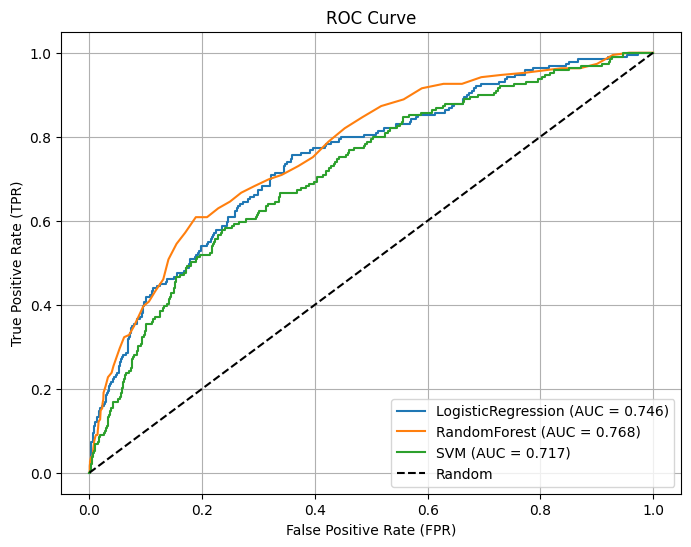

In [12]:
plt.figure(figsize=(8,6))

for name, pipeline in results.items():
    if hasattr(pipeline.named_steps['classifier'], "predict_proba"):
        y_proba = pipeline.predict_proba(X_test)[:,1]
    else:
        y_proba = pipeline.decision_function(X_test)

    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# Test

In [13]:
ID = Bacteriemie_test['ID']
y_pred_new = results['LogisticRegression'].predict(Bacteriemie_test)

resultats_test = pd.DataFrame({
    'ID': ID.values,
    'BloodCulture': y_pred_new
})

#resultats_test[BloodCulture].value_counts()

In [14]:
resultats_test.to_csv('Final.csv', index=False)

In [15]:
resultats_test.to_csv('Final.csv', index=False)